In [1]:
# The City College of New York, City University of New York
# Written by Olga Chsherbakova in October, 2023
# Simplified by Hasan Suca Kayman in 2025
# Modified by Reaz Uddin Bhuiyan in 2026

In [2]:
from tensorflow.keras import layers, models, optimizers
import os
import numpy as np
from PIL import Image
import pandas as pd
from IPython.display import HTML, display
from google.colab.output import eval_js
from base64 import b64decode
import asyncio
from google.colab import output
import matplotlib.pyplot as plt
import numpy as np
import random
from re import VERBOSE

In [3]:
async def draw_tool(filename='drawing.png', w=100, h=100, line_width=1):
    canvas_id = f"canvas_{np.random.randint(10000)}"
    button_id = f"button_{np.random.randint(10000)}"
    canvas_html = f"""
    <canvas id="{canvas_id}" width={w} height={h} style="border: 2px solid red;"></canvas>
    <button id="{button_id}">Finish</button>
    <script>
    var canvas = document.getElementById('{canvas_id}')
    var ctx = canvas.getContext('2d')
    ctx.lineWidth = {line_width}
    var button = document.getElementById('{button_id}')
    var mouse = {{x: 0, y: 0}}
    canvas.addEventListener('mousemove', function(e) {{
      mouse.x = e.pageX - this.offsetLeft
      mouse.y = e.pageY - this.offsetTop
    }})
    canvas.onmousedown = ()=>{{
      ctx.beginPath()
      ctx.moveTo(mouse.x, mouse.y)
      canvas.addEventListener('mousemove', onPaint)
    }}
    canvas.onmouseup = ()=>{{
      canvas.removeEventListener('mousemove', onPaint)
    }}
    var onPaint = ()=>{{
      ctx.lineTo(mouse.x, mouse.y)
      ctx.stroke()
    }}
    var data_{canvas_id} = new Promise(resolve=>{{
      button.onclick = ()=>{{
        resolve(canvas.toDataURL('image/png'))
      }}
    }})
    </script>
    """
    display(HTML(canvas_html))
    data = eval_js(f"data_{canvas_id}")
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
      f.write(binary)
    return filename

def print_weights(weights):
    # weights = model.get_weights();
    print('\n******* WEIGHTS OF ANN *******\n')
    for i in range(int(len(weights)/2)):
        print('Weights W%d:\n' %(i), weights[i*2])
        print('Bias b%d:\n' %(i), weights[(i*2)+1])

In [4]:
# Train a new CNN using information from TrainingSet directory
# Then return trained CNN
# TRAIN THE CNN

# select training directory
train_dir = './sample_data/mnist_test.csv'
print('WELCOME TO USING CNN.')
#print('Be patient until statistics are displayed...')

# load the training image dataset into an ImageDatasGenerator
# train_path contains the path to the dataset
data = pd.read_csv(train_dir)
data = data.iloc[:1000,:]
train_label = np.eye(10)[data.iloc[:,0].values]
train_data = data.iloc[:,1:].values.astype(np.float32) / 255.0
train_data = train_data.reshape(-1,28,28,1)

WELCOME TO USING CNN.


First 5 input images (28x28):


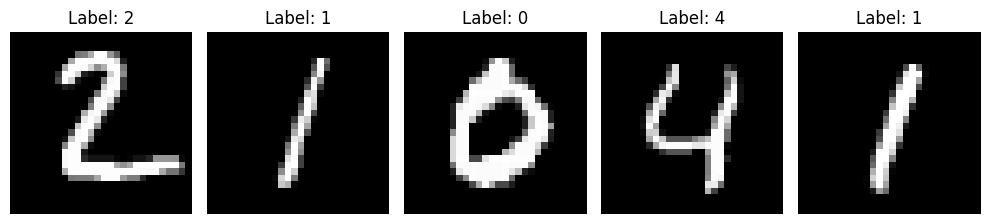

First 5 input images (28x28):

Image 0 (Label: 2):
[[0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00]
 [0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00]
 [0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00]
 [0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.45 0.49 0.67 1.00 1.00 0.59 0.36 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00]
 [0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.66 0.99 0.99 0.99 0.99 0.99 0.99 0.85 0.12 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00]
 [0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.66 0.99 0.99 0.99 0.84 0.56 0.69 0.99 0.99 0.48 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00]
 [0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.20 0.98 0.99 0.82 0.13 0.05 0.00 0.02 0.81 0.99 0.55

In [5]:
print("First 5 input images (28x28):")
fig, axes = plt.subplots(1, 5, figsize=(10, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(train_data[i,:,:,0], cmap='gray')
    ax.set_title(f"Label: {np.argmax(train_label[i])}")
    ax.axis('off')
plt.tight_layout()
plt.show()

print("First 5 input images (28x28):")
for i in range(5):
    print(f"\nImage {i} (Label: {np.argmax(train_label[i])}):")
    np.set_printoptions(linewidth=200, formatter={'float': lambda x: f'{x:.2f}'})
    print(train_data[i,:,:,0])

print("\nFirst 5 output labels (one-hot encoded):")
for i in range(5):
    print(f"Label {i}: ", train_label[i])

In [6]:
# Define the CNN structure
model = models.Sequential([
    # set the size of the input image as 28x28 pixels with 1 color
    # channel (grayscale)
    layers.InputLayer(input_shape=(28, 28, 1)),
    # create the first convolution layer, it has 8 convolutional
    # filters, each with a height and width of 3 and input is 0 padded.
    # the input is padded with the appropriate number of zeros so that
    # the size of the output is the same size as the input.
    layers.Conv2D(8, (3, 3), padding='same'),
    # normalize the output of the convolution between the range -1
    # and 1. this prevents the updated weights from increasing
    # explosively during training.
    layers.BatchNormalization(),
    # apply rectilinear unit activation function that sets all negative
    # values to zero
    layers.Activation('relu'),
    # apply max pooling using a pooling size of (2x2), and using a
    # stride of 2
    layers.MaxPooling2D((2, 2), strides=2),

    # create a second convolution layer, it has 16 convolutional
    # filters, each filter has a height and width of 3 and the input is
    # zero padded.
    layers.Conv2D(16, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    # apply max pooling using a pooling size of (2x2), and using a
    # stride of 2
    layers.MaxPooling2D((2, 2), strides=2),

    # create a third convolution layer, it has 32 convolutional
    # filters, each filter has a height and width of 3 and the input is
    # zero padded.
    layers.Conv2D(32, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Flatten(),
    layers.Dense(100, activation='relu'),
    layers.Dense(10,
                  # use a softmax layer to convert the outputs to a set of
                  # probalities where each output represents the
                  # probability that the image is a corresponding label.
                  activation='softmax')
])
# END OF layers

# optimizer to be used during training. In this case,
# the Adam optimizer is used. The optimizer is responsible for updating
# the model's weights during training based on the computed gradients.
# Adam is a popular optimization algorithm that adapts the learning
# rate during training.
model.compile(optimizer=optimizers.Adam(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       156,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,022 (640.71 KB)

 Trainable params: 163,910 (640.27 KB)

 Non-trainable params: 112 (448.00 B)

In [7]:
print('\nInitial weights and biases before training:')
print_weights(model.get_weights())


Initial weights and biases before training:

******* WEIGHTS OF ANN *******

Weights W0:
 [[[[0.11 0.17 0.08 0.24 0.18 -0.04 0.09 -0.07]]

  [[-0.24 0.12 0.27 -0.03 0.27 0.20 -0.21 -0.01]]

  [[-0.12 -0.07 -0.17 -0.18 0.14 -0.11 -0.20 0.19]]]


 [[[-0.04 0.25 0.25 0.05 -0.22 0.24 -0.23 -0.12]]

  [[-0.11 -0.18 -0.12 -0.21 0.04 -0.15 0.01 0.03]]

  [[0.21 -0.17 0.00 -0.20 -0.21 -0.01 0.21 -0.12]]]


 [[[-0.16 -0.02 0.05 0.18 0.05 -0.04 -0.09 -0.01]]

  [[0.04 -0.07 0.19 0.23 -0.13 0.16 0.03 -0.22]]

  [[-0.23 -0.09 -0.10 0.25 0.07 -0.05 0.10 -0.26]]]]
Bias b0:
 [0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00]
Weights W1:
 [1.00 1.00 1.00 1.00 1.00 1.00 1.00 1.00]
Bias b1:
 [0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00]
Weights W2:
 [0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00]
Bias b2:
 [1.00 1.00 1.00 1.00 1.00 1.00 1.00 1.00]
Weights W3:
 [[[[0.08 0.11 -0.01 ... 0.07 0.12 0.08]
   [0.15 -0.13 0.06 ... 0.07 -0.11 -0.05]
   [0.02 -0.15 -0.02 ... -0.00 0.08 0.03]
   ...
   [-0.09 -0.06 0.17 ... 0.12 0.

In [8]:
# specify CNN training options
model.fit(x=train_data, y=train_label, epochs=100)
print('CNN is trained.')

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.6790 - loss: 1.0040
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9300 - loss: 0.2373
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9690 - loss: 0.1179
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.9930 - loss: 0.0466
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9980 - loss: 0.0242
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 1.0000 - loss: 0.0137
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 1.0000 - loss: 0.0091
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 1.0000 - loss: 0.0066
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 1.0000 - loss: 0.0050
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 1.0000 - loss: 0.0043
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 1.0000 - loss: 0.0037
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step

In [9]:
print('\nWeights and biases after training:')
print_weights(model.get_weights())


Weights and biases after training:

******* WEIGHTS OF ANN *******

Weights W0:
 [[[[0.12 0.17 0.06 0.22 0.17 -0.03 0.10 -0.07]]

  [[-0.26 0.11 0.26 -0.06 0.25 0.19 -0.23 -0.01]]

  [[-0.12 -0.08 -0.19 -0.17 0.16 -0.09 -0.21 0.20]]]


 [[[-0.02 0.24 0.25 0.04 -0.23 0.29 -0.22 -0.13]]

  [[-0.14 -0.19 -0.10 -0.20 0.02 -0.14 0.01 0.02]]

  [[0.20 -0.17 0.00 -0.20 -0.22 0.01 0.21 -0.10]]]


 [[[-0.14 -0.01 0.07 0.17 0.03 -0.02 -0.06 -0.01]]

  [[0.00 -0.07 0.20 0.27 -0.15 0.16 0.04 -0.21]]

  [[-0.21 -0.08 -0.09 0.25 0.05 -0.03 0.11 -0.24]]]]
Bias b0:
 [0.00 0.01 -0.01 0.01 -0.01 0.00 -0.01 -0.00]
Weights W1:
 [1.00 1.01 0.99 0.98 1.02 0.97 1.02 1.02]
Bias b1:
 [0.01 -0.01 -0.00 -0.02 -0.00 -0.01 -0.01 0.01]
Weights W2:
 [-0.07 -0.00 0.05 0.05 0.00 0.05 -0.04 -0.07]
Bias b2:
 [0.02 0.01 0.02 0.02 0.01 0.01 0.01 0.02]
Weights W3:
 [[[[0.10 0.11 -0.04 ... 0.04 0.11 0.08]
   [0.17 -0.13 0.03 ... 0.07 -0.09 -0.06]
   [0.03 -0.18 -0.03 ... 0.00 0.10 0.02]
   ...
   [-0.08 -0.09 0.15 ... 0.13

In [10]:
print('\n\nCharacter Recognition Using CNN\nDraw a number 0-9 to predict it')
image_path = await draw_tool()

# Load and preprocess the image
img = Image.open(image_path)  # Convert to grayscale
img = img.resize((28, 28))
img = np.array(img).astype(np.float32)
img = img[:,:,3]

# Reshape for model input (add batch and channel dimensions)
char_img_array = img.reshape(1, 28, 28, 1)

print("\nDrawn image (28x28 pixel values):")
np.set_printoptions(linewidth=200, formatter={'float': lambda x: f'{x:.2f}'})
print(char_img_array[0,:,:,0] / 255)



Character Recognition Using CNN
Draw a number 0-9 to predict it



Drawn image (28x28 pixel values):
[[0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00]
 [0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00]
 [0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.06 0.07 0.07 0.07 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00]
 [0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.02 0.28 0.54 0.51 0.51 0.51 0.55 0.55 0.01 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00]
 [0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.52 0.44 0.11 0.00 0.00 0.00 0.00 0.44 0.38 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00]
 [0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.01 0.44 0.35 0.00 0.00 0.00 0.00 0.00 0.00 0.07 0.57 0.01 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00]
 [0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.02 0.24 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.01 0.55 0.07 0.00 0.00 

In [11]:
# Make a prediction
predictions = model.predict(char_img_array)
predicted_class = np.argmax(predictions)

## display prediction
print('\n*******************************')
print('CNN Prediction: ', int(predicted_class))
# print('*******************************')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step

*******************************
CNN Prediction:  3


In [12]:
# ask user if they would like to save the ANN model
choice = ''
while choice not in ['y','n']:
    choice = input('\n\nWould you like to save the CNN model? (y/n): \n')
    if choice == 'y':
        save_name = input('\n\nEnter a name for the save file: \n')
        ## if file name does not end with '.h5', add '.h5' to the file name
        if save_name[-3:] != '.h5':
            save_name += '.h5'
        model.save(save_name)
        print('\n\n')
        print('***** CNN MODEL SUCCESSFULLY SAVED AS '+save_name+' *****')
    elif choice == 'n':
        pass
    else:
        print("Invalid input: Input must be 'y' or 'n'")



Would you like to save the CNN model? (y/n): 
y


Enter a name for the save file: 
8049





***** CNN MODEL SUCCESSFULLY SAVED AS 8049.h5 *****
